In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [20]:
df = pd.read_csv("preprocessed_loan_data.csv")
df

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,1,1,2,24240.19,2020.02,0,0.074,743,17173.72,...,36,581.88,9,7,40833.47,24302.07,1,0,1,1
1,72,0,1,0,20172.98,1681.08,0,0.219,531,22663.89,...,60,573.17,25,5,27968.01,10803.01,1,0,3,1
2,49,0,2,1,26181.80,2181.82,0,0.234,779,3631.36,...,60,76.32,8,2,15502.25,4505.44,0,0,0,1
3,35,0,2,1,11873.84,989.49,0,0.264,809,14939.23,...,36,468.07,4,7,18157.79,5525.63,4,0,5,1
4,63,2,2,3,25326.44,2110.54,0,0.260,663,16551.71,...,60,395.50,19,1,17467.56,3593.91,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,39,0,1,0,39640.08,3303.34,0,0.275,691,16322.23,...,36,566.22,14,2,23748.10,5801.45,1,0,4,0
19996,66,0,1,0,32062.90,2671.91,0,0.367,758,16697.34,...,36,553.71,9,8,49929.65,40901.31,3,0,3,1
19997,65,0,2,2,18642.02,1553.50,3,0.106,751,23924.78,...,36,772.66,8,3,13137.57,5075.67,1,0,2,1
19998,35,1,1,2,22181.39,1848.45,1,0.275,646,16920.13,...,36,595.36,16,5,19580.82,3876.16,4,0,5,1


In [21]:
# Encoding Categorical Columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_columns = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

    df.head()

In [22]:
# Seperate Input and Output
indep_X = df.drop("loan_paid_back", axis = 1)
dep_Y = df["loan_paid_back"]

In [23]:
# Train,Test and Split

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(indep_X, dep_Y, test_size = 0.25, random_state = 42)


In [24]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit(X_test)


# Univariate

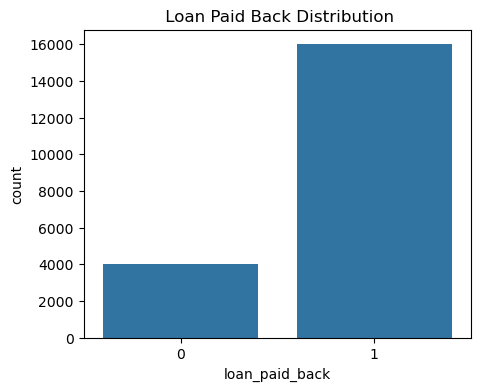

In [25]:
# Target Variable Distribution

plt.figure(figsize = (5,4))
sns.countplot( x = 'loan_paid_back', data = df)
plt.title(" Loan Paid Back Distribution")
plt.show()

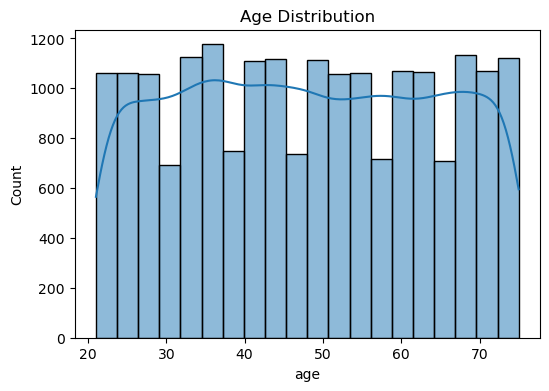

In [26]:
# Age Distribution 

plt.figure(figsize = (6,4))
sns.histplot(df['age'], bins = 20, kde = True)
plt.title("Age Distribution")
plt.show()

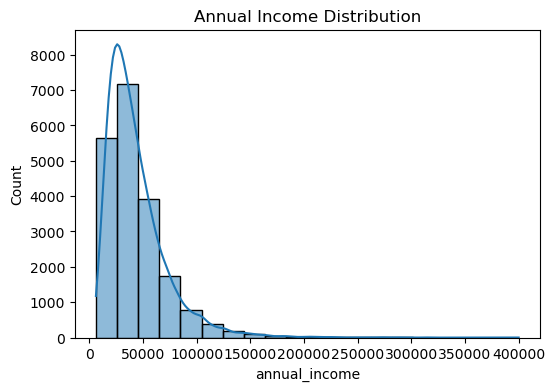

In [27]:
# Annual income distribution

plt.figure(figsize = (6,4))
sns.histplot(df['annual_income'], bins = 20, kde = True)
plt.title('Annual Income Distribution')
plt.show()

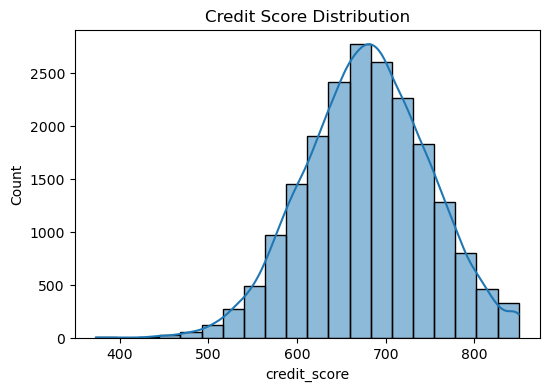

In [28]:
# credit score distribution

plt.figure(figsize = (6,4))
sns.histplot(df['credit_score'], bins = 20, kde = True)
plt.title('Credit Score Distribution')
plt.show()

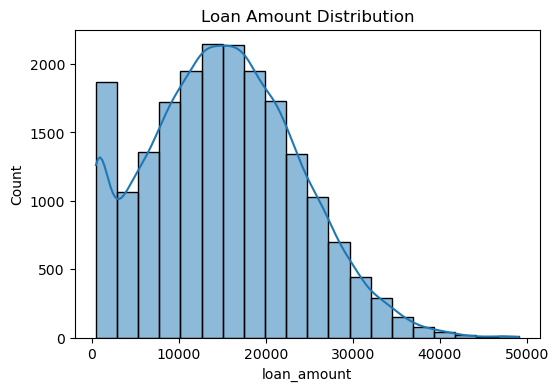

In [29]:
# Loan Amount Distribution

plt.figure(figsize = (6,4))
sns.histplot(df['loan_amount'], bins = 20, kde = True)
plt.title("Loan Amount Distribution")
plt.show()

# 2. Bivariate

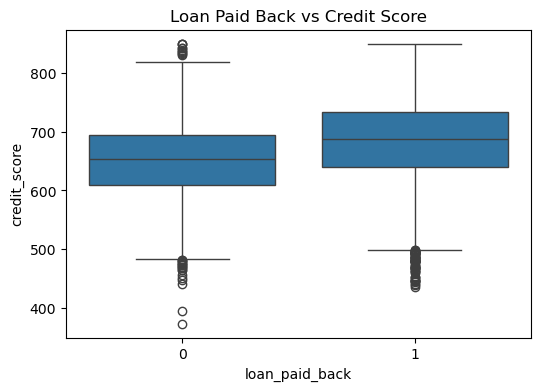

In [30]:
# loan paid back vs credit score

plt.figure(figsize=(6,4))
sns.boxplot( x = 'loan_paid_back', y = 'credit_score', data = df)
plt.title("Loan Paid Back vs Credit Score")
plt.show()

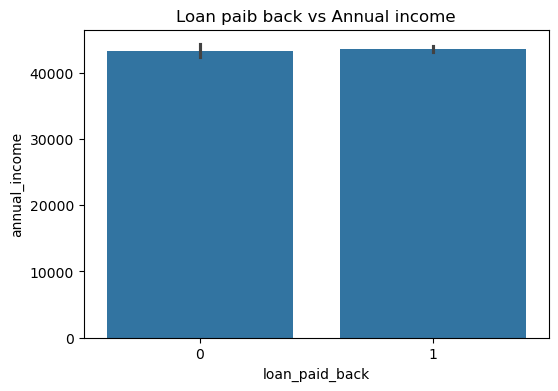

In [31]:
# load paid back vs annual income

plt.figure(figsize = (6,4))
sns.barplot(x = 'loan_paid_back', y = 'annual_income', data = df)
plt.title("Loan paib back vs Annual income")
plt.show()

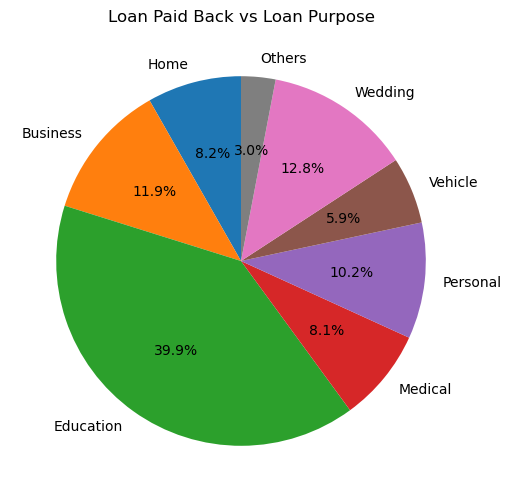

In [32]:
# Loan purpose vs Loan paid back 

loan_labels = {0: 'Home', 1:'Business', 2: 'Education', 3:'Medical', 4:'Personal', 5:'Vehicle', 6:'Wedding', 7:'Others'}
loan_purpose =df.groupby('loan_purpose')['loan_paid_back'].sum()

plt.figure(figsize=(6,6))
plt.pie(loan_purpose, labels =[ loan_labels[i] for i in loan_purpose.index], autopct = '%1.1f%%',
        startangle = 90)
plt.title("Loan Paid Back vs Loan Purpose")
plt.show()

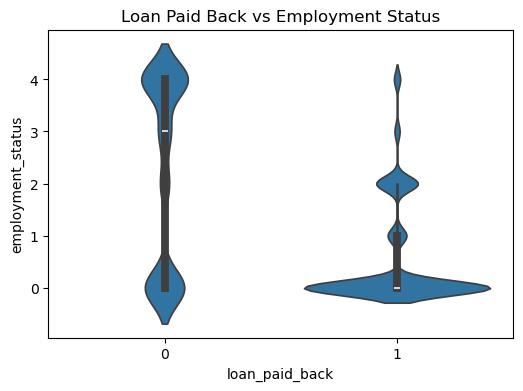

In [33]:
# loan paid back vs employment status

plt.figure(figsize = (6,4))
sns.violinplot(x ='loan_paid_back', y ='employment_status', data = df)
plt.title("Loan Paid Back vs Employment Status")
plt.show()

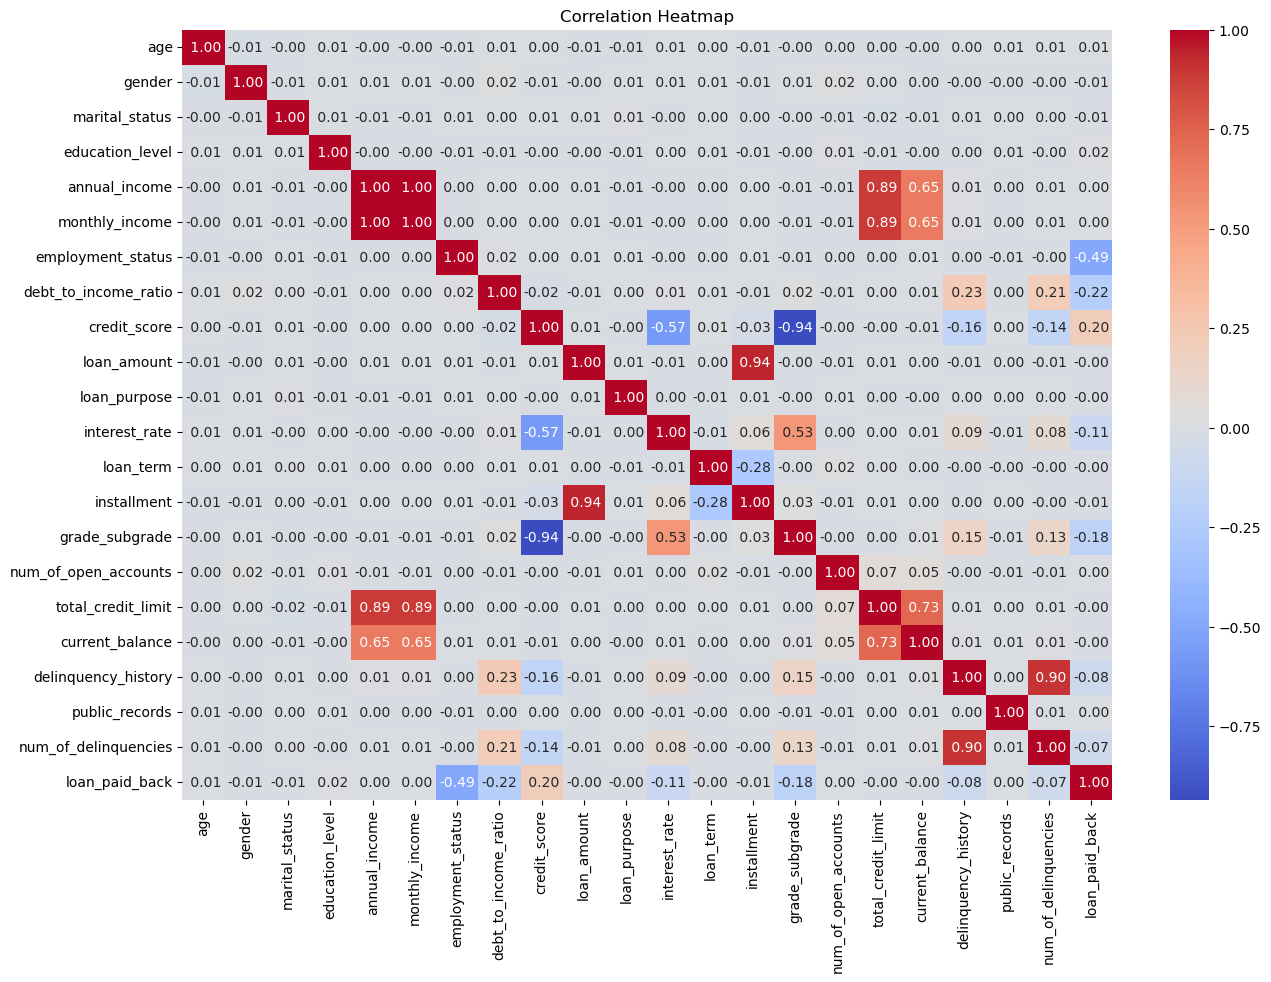

In [34]:
# correlatin heatmap
plt.figure(figsize = (15,10))
sns.heatmap(df.corr(), annot = True, cmap ='coolwarm', fmt = ' .2f')
plt.title('Correlation Heatmap')
plt.show()